# PBS Multi Measure

여러 PBS CSV에서 시간별 Vth를 계산하고, 각 데이터의 Delta Vth vs time을 한 그래프에 겹쳐 그립니다.

In [70]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True


In [71]:
# CSV path 입력
# fixed Vd = 0V : Vg = 1.0V / 2.2V / 4.5V

dataset_infos = [
    {"path": "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R0(1) ; 4_15_2026 9_22_52 AM].csv", "vg": 1.0, "vd": 0, "data_idx": 1},
    {"path": "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R1(2) ; 4_15_2026 10_09_07 AM].csv", "vg": 1.0, "vd": 0, "data_idx": 2},
    {"path": "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R2(3) ; 4_15_2026 11_01_47 AM].csv", "vg": 1.0, "vd": 0, "data_idx": 3},
    {"path": "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R0(10) ; 4_16_2026 9_23_10 AM].csv", "vg": 2.2, "vd": 0, "data_idx": 1},
    {"path": "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R1(11) ; 4_16_2026 10_00_03 AM].csv", "vg": 2.2, "vd": 0, "data_idx": 2},
    {"path": "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R2(12) ; 4_16_2026 10_35_54 AM].csv", "vg": 2.2, "vd": 0, "data_idx": 3},
    {"path": "PBTI_IGZO_new2 [260331_WF02_#5_MID_UNITTR_PBS_VD0V_R1(4) ; 4_14_2026 10_03_36 AM].csv", "vg": 4.5, "vd": 0, "data_idx": 1},
    {"path": "PBTI_IGZO_new2 [260331_WF02_#5_MID_UNITTR_PBS_VD0V_R2(5) ; 4_14_2026 10_39_22 AM].csv", "vg": 4.5, "vd": 0, "data_idx": 2},
    {"path": "PBTI_IGZO_new2 [260331_WF02_#5_MID_UNITTR_PBS_VD0V_R3(6) ; 4_14_2026 11_17_30 AM].csv", "vg": 4.5, "vd": 0, "data_idx": 3},
]

for info in dataset_infos:
    info["label"] = f"Vg={info['vg']}[V], Vd={info['vd']}[V] data{info['data_idx']}"

dataset_infos


[{'path': 'PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R0(1) ; 4_15_2026 9_22_52 AM].csv',
  'vg': 1.0,
  'vd': 0,
  'data_idx': 1,
  'label': 'Vg=1.0[V], Vd=0[V] data1'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R1(2) ; 4_15_2026 10_09_07 AM].csv',
  'vg': 1.0,
  'vd': 0,
  'data_idx': 2,
  'label': 'Vg=1.0[V], Vd=0[V] data2'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R2(3) ; 4_15_2026 11_01_47 AM].csv',
  'vg': 1.0,
  'vd': 0,
  'data_idx': 3,
  'label': 'Vg=1.0[V], Vd=0[V] data3'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R0(10) ; 4_16_2026 9_23_10 AM].csv',
  'vg': 2.2,
  'vd': 0,
  'data_idx': 1,
  'label': 'Vg=2.2[V], Vd=0[V] data1'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R1(11) ; 4_16_2026 10_00_03 AM].csv',
  'vg': 2.2,
  'vd': 0,
  'data_idx': 2,
  'label': 'Vg=2.2[V], Vd=0[V] data2'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_V

In [72]:
def load_pbs_csv(path):
    rows = []
    with open(path, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            rows.append(row)

    max_len = max(len(row) for row in rows)
    rows = [row + [""] * (max_len - len(row)) for row in rows]
    raw_data = pd.DataFrame(rows)

    is_datavalue = raw_data[0].isin(["DataValue"])
    raw_data = raw_data[is_datavalue].copy()
    raw_data = raw_data.iloc[:, 1:6]
    raw_data.columns = ["Vgate", "Vdrain", "Idrain", "IdMax", "Vth@Id"]

    df = raw_data.copy()
    time_series = df.loc[df["Idrain"].isin([" "]), "Vgate"]
    time_list = list(reversed(time_series.tolist()))
    time_count = len(time_list)
    df = df.iloc[time_count:, :].copy()

    df["IdMax"] = pd.to_numeric(df["IdMax"], errors="coerce")
    df["block"] = df["IdMax"].notna().cumsum()
    df = df[df["block"] > 0].copy()

    mapping = {i + 1: t for i, t in enumerate(time_list)}
    df["time_s"] = df["block"].map(mapping)

    df["Vgate"] = pd.to_numeric(df["Vgate"], errors="coerce")
    df["Vdrain"] = pd.to_numeric(df["Vdrain"], errors="coerce")
    df["Idrain"] = pd.to_numeric(df["Idrain"], errors="coerce").abs()
    df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")

    return df.dropna(subset=["Vgate", "Idrain", "time_s"]).copy()


W_um = 40
L_um = 20
W_over_L = W_um / L_um
L_m = L_um * 1e-6
Cox_total_F = 4.25e-12

def extract_vth_by_time(df, target_log_id=-10):
    vth_by_time = {}

    for time_s, group in df.groupby("time_s"):
        group = group.sort_values("Vgate")
        vg = group["Vgate"].to_numpy()
        idrain = group["Idrain"].to_numpy()

        abs_id = np.clip(np.abs(idrain), 1e-300, None)
        norm_id = abs_id / W_over_L
        log_i = np.log10(norm_id)
        diff = log_i - target_log_id
        cross_idx = np.where(diff[:-1] * diff[1:] <= 0)[0]

        if len(cross_idx) == 0:
            vth_by_time[time_s] = np.nan
            continue

        idx = cross_idx[0]
        x0, x1 = vg[idx], vg[idx + 1]
        y0, y1 = log_i[idx], log_i[idx + 1]

        if y1 == y0:
            vth_by_time[time_s] = np.nan
        else:
            vth_by_time[time_s] = x0 + (target_log_id - y0) * (x1 - x0) / (y1 - y0)

    return dict(sorted(vth_by_time.items()))


def extract_ss_by_time(df, target_log_id_low=-10, target_log_id_high=-9):
    ss_by_time = {}

    for time_s, group in df.groupby("time_s"):
        group = group.sort_values("Vgate")
        vg = group["Vgate"].to_numpy()
        idrain = group["Idrain"].to_numpy()

        abs_id = np.clip(np.abs(idrain), 1e-300, None)
        norm_id = abs_id / W_over_L
        log_i = np.log10(norm_id)

        diff_low = log_i - target_log_id_low
        diff_high = log_i - target_log_id_high
        cross_idx_low = np.where(diff_low[:-1] * diff_low[1:] <= 0)[0]
        cross_idx_high = np.where(diff_high[:-1] * diff_high[1:] <= 0)[0]

        if len(cross_idx_low) == 0 or len(cross_idx_high) == 0:
            ss_by_time[time_s] = np.nan
            continue

        i_low = cross_idx_low[0]
        i_high = cross_idx_high[0]

        x0, x1 = vg[i_low], vg[i_low + 1]
        y0, y1 = log_i[i_low], log_i[i_low + 1]

        z0, z1 = vg[i_high], vg[i_high + 1]
        t0, t1 = log_i[i_high], log_i[i_high + 1]

        if y1 == y0 or t1 == t0:
            ss_by_time[time_s] = np.nan
            continue

        vg_low = x0 + (target_log_id_low - y0) * (x1 - x0) / (y1 - y0)
        vg_high = z0 + (target_log_id_high - t0) * (z1 - z0) / (t1 - t0)

        ss_v_per_dec = (vg_high - vg_low) / (target_log_id_high - target_log_id_low)
        ss_by_time[time_s] = ss_v_per_dec * 1000

    return dict(sorted(ss_by_time.items()))


def extract_mobility_by_time(df, cox_total_f=Cox_total_F, channel_length_m=L_m):
    mobility_by_time = {}
    gmmax_by_time = {}
    vd_used_by_time = {}

    for time_s, group in df.groupby("time_s"):
        group = group.sort_values(["Vdrain", "Vgate"]).copy()
        vdrain_values = np.sort(group["Vdrain"].dropna().unique())
        nonzero_vd = vdrain_values[np.abs(vdrain_values) > 0]

        if len(nonzero_vd) == 0:
            mobility_by_time[time_s] = np.nan
            gmmax_by_time[time_s] = np.nan
            vd_used_by_time[time_s] = np.nan
            continue

        vd_for_mu = float(nonzero_vd[np.argmin(np.abs(nonzero_vd))])
        branch = group[np.isclose(group["Vdrain"], vd_for_mu, rtol=1e-6, atol=1e-9)].copy()
        branch = branch.sort_values("Vgate")

        if len(branch) < 3:
            mobility_by_time[time_s] = np.nan
            gmmax_by_time[time_s] = np.nan
            vd_used_by_time[time_s] = vd_for_mu
            continue

        vg = branch["Vgate"].to_numpy(dtype=float)
        idrain = branch["Idrain"].to_numpy(dtype=float)
        gm = np.gradient(idrain, vg)
        gm_max = np.nanmax(gm)

        if np.isnan(gm_max) or vd_for_mu == 0:
            mu_cm2_vs = np.nan
        else:
            mu_m2_vs = gm_max * (channel_length_m ** 2) / (cox_total_f * abs(vd_for_mu))
            mu_cm2_vs = mu_m2_vs * 1e4

        mobility_by_time[time_s] = mu_cm2_vs
        gmmax_by_time[time_s] = gm_max
        vd_used_by_time[time_s] = vd_for_mu

    return (
        dict(sorted(mobility_by_time.items())),
        dict(sorted(gmmax_by_time.items())),
        dict(sorted(vd_used_by_time.items())),
    )


def build_delta_vth(vth_by_time):
    valid_times = [t for t, v in vth_by_time.items() if not np.isnan(v)]
    if not valid_times:
        return np.nan, {}

    ref_time = min(valid_times)
    ref_vth = vth_by_time[ref_time]
    delta_vth_by_time = {}

    for time_s, vth in vth_by_time.items():
        if np.isnan(vth) or np.isnan(ref_vth):
            delta_vth_by_time[time_s] = np.nan
        else:
            delta_vth_by_time[time_s] = vth - ref_vth

    return ref_vth, delta_vth_by_time


In [73]:
results = []

for info in dataset_infos:
    df_single = load_pbs_csv(info["path"])
    vth_by_time = extract_vth_by_time(df_single, target_log_id=-10)
    ss_by_time = extract_ss_by_time(df_single, target_log_id_low=-10, target_log_id_high=-9)
    mobility_by_time, gmmax_by_time, vd_used_by_time = extract_mobility_by_time(df_single)
    initial_vth, delta_vth_by_time = build_delta_vth(vth_by_time)

    results.append({
        **info,
        "df": df_single,
        "vth_by_time": vth_by_time,
        "ss_by_time": ss_by_time,
        "mobility_by_time": mobility_by_time,
        "gmmax_by_time": gmmax_by_time,
        "vd_used_by_time": vd_used_by_time,
        "initial_vth": initial_vth,
        "delta_vth_by_time": delta_vth_by_time,
    })

for result in results:
    print(result["label"])
    print(f"  initial Vth = {result['initial_vth']:.4f} V")
    print(f"  times = {list(result['delta_vth_by_time'].keys())}")


Vg=1.0[V], Vd=0[V] data1
  initial Vth = 0.2371 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=0[V] data2
  initial Vth = 0.2772 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=0[V] data3
  initial Vth = 0.2656 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=0[V] data1
  initial Vth = 0.1563 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=0[V] data2
  initial Vth = 0.0782 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=0[V] data3
  initial Vth = 0.1410 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=4.5[V], Vd=0[V] data1
  initial Vth = 0.1841 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=4.5[V], Vd=0[V] data2
  initial Vth = 0.2477 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=4.5[V], Vd=0[V] data3
  initial Vth = 0.2211 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]


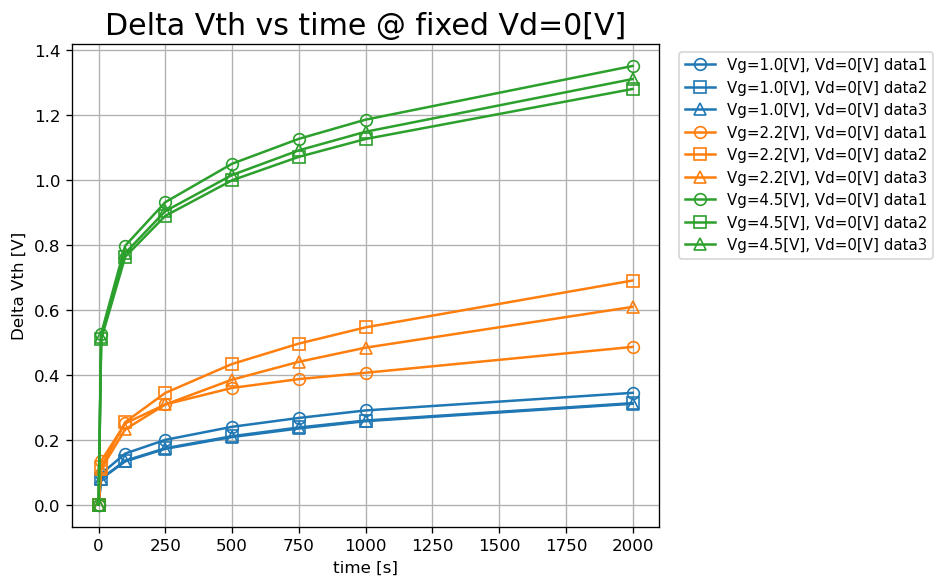

In [74]:
unique_vg_values = sorted({result["vg"] for result in results})
unique_vd_values = sorted({result["vd"] for result in results})

vg_palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
vg_color_map = {vg: vg_palette[i % len(vg_palette)] for i, vg in enumerate(unique_vg_values)}

data_marker_map = {
    1: 'o',
    2: 's',
    3: '^',
}

plt.figure(figsize=(8, 5))

for result in results:
    delta_series = pd.Series(result["delta_vth_by_time"]).sort_index()
    line_color = vg_color_map.get(result["vg"], 'black')
    line_marker = data_marker_map.get(result["data_idx"], 'o')

    plt.plot(
        delta_series.index.to_numpy(),
        delta_series.to_numpy(),
        color=line_color,
        marker=line_marker,
        markerfacecolor='none',
        markersize=7,
        linewidth=1.5,
        label=result["label"],
    )

plt.xlabel('time [s]')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth vs time @ fixed Vd=0[V]', fontsize=18)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


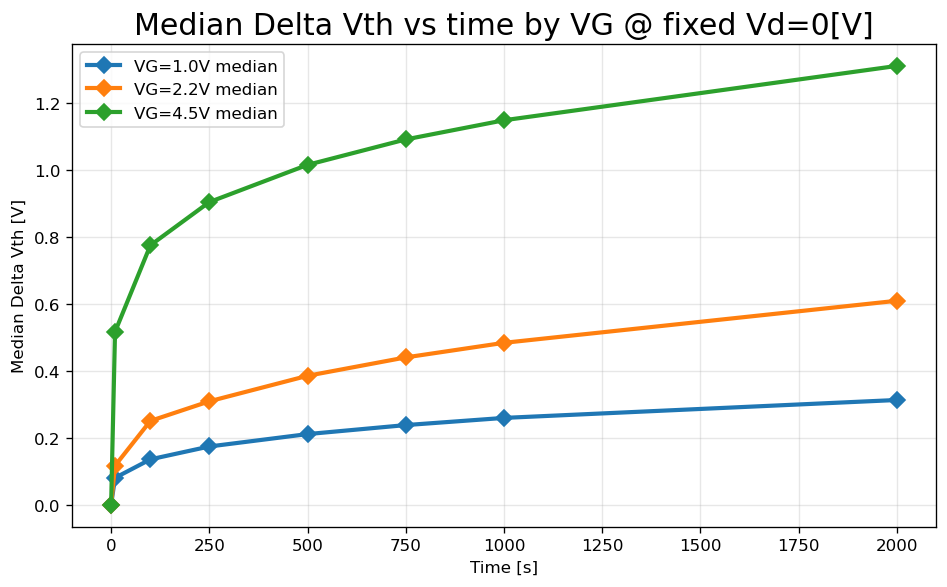

,vg,time_s,delta_vth
0,1.0,0,0.000000
1,1.0,10,0.080304
2,1.0,100,0.135574
3,1.0,250,0.173987
4,1.0,500,0.211033
5,1.0,750,0.237921
6,1.0,1000,0.259368
7,1.0,2000,0.312887
8,2.2,0,0.000000
9,2.2,10,0.116724


In [75]:
median_rows = []

for result in results:
    for time_s, delta_vth in result["delta_vth_by_time"].items():
        if pd.notna(delta_vth):
            median_rows.append({
                "vg": result["vg"],
                "time_s": time_s,
                "delta_vth": delta_vth,
            })

median_df = pd.DataFrame(median_rows)
median_df = median_df.groupby(["vg", "time_s"], as_index=False)["delta_vth"].median()

plt.figure(figsize=(8, 5))

for vg, group in median_df.groupby("vg"):
    group = group.sort_values("time_s")
    plt.plot(
        group["time_s"].to_numpy(),
        group["delta_vth"].to_numpy(),
        color=vg_color_map.get(vg, "black"),
        marker="D",
        linewidth=2.5,
        markersize=7,
        label=f"VG={vg}V median",
    )

plt.xlabel("Time [s]")
plt.ylabel("Median Delta Vth [V]")
plt.title("Median Delta Vth vs time by VG @ fixed Vd=0[V]", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

median_df


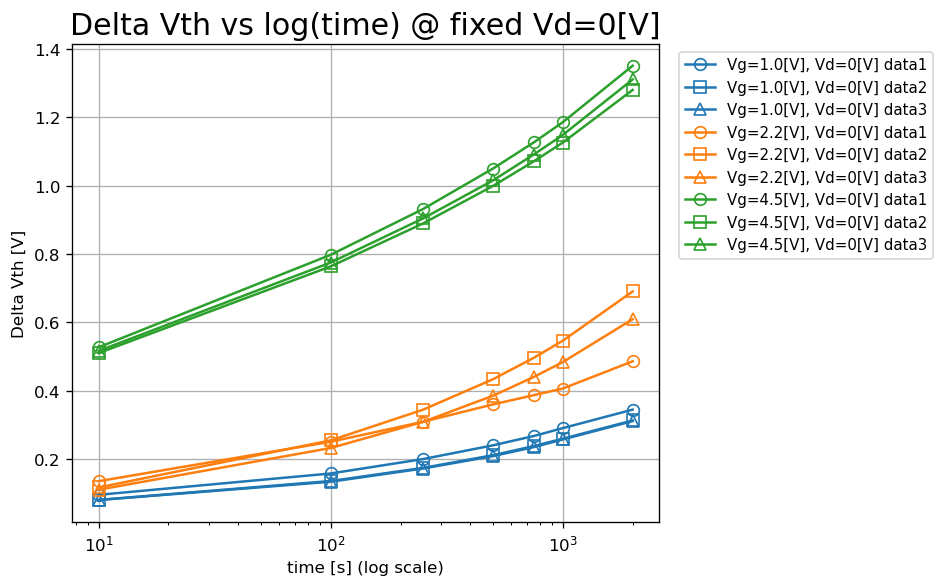

In [76]:
plt.figure(figsize=(8, 5))

for result in results:
    delta_series = pd.Series(result["delta_vth_by_time"]).sort_index()
    delta_series = delta_series[delta_series.index > 0]
    line_color = vg_color_map.get(result["vg"], 'black')
    line_marker = data_marker_map.get(result["data_idx"], 'o')

    plt.plot(
        delta_series.index.to_numpy(),
        delta_series.to_numpy(),
        color=line_color,
        marker=line_marker,
        markerfacecolor='none',
        markersize=7,
        linewidth=1.5,
        label=result["label"],
    )

plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth vs log(time) @ fixed Vd=0[V]', fontsize=18)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


In [77]:
all_times = sorted({time_s for result in results for time_s in result["delta_vth_by_time"].keys()})

summary_rows = []
for result in results:
    row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
        "initial_vth[V]": result["initial_vth"],
    }

    for time_s in all_times:
        row[f"delta_vth@{int(time_s)}s[V]"] = result["delta_vth_by_time"].get(time_s, np.nan)

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["stress_vd[V]", "stress_vg[V]", "data_idx"] if "data_idx" in summary_df.columns else ["stress_vd[V]", "stress_vg[V]", "legend"]).reset_index(drop=True)

display(summary_df.round(4))


,legend,stress_vg[V],stress_vd[V],initial_vth[V],delta_vth@0s[V],delta_vth@10s[V],delta_vth@100s[V],delta_vth@250s[V],delta_vth@500s[V],delta_vth@750s[V],delta_vth@1000s[V],delta_vth@2000s[V]
0,"Vg=1.0[V], Vd=0[V] data1",1.0,0,0.2371,0.0,0.0952,0.1576,0.1998,0.2400,0.2673,0.2904,0.3446
1,"Vg=1.0[V], Vd=0[V] data2",1.0,0,0.2772,0.0,0.0803,0.1356,0.1740,0.2110,0.2379,0.2594,0.3129
2,"Vg=1.0[V], Vd=0[V] data3",1.0,0,0.2656,0.0,0.0799,0.1335,0.1721,0.2085,0.2348,0.2573,0.3110
3,"Vg=2.2[V], Vd=0[V] data1",2.2,0,0.1563,0.0,0.1350,0.2504,0.3089,0.3597,0.3869,0.4063,0.4860
4,"Vg=2.2[V], Vd=0[V] data2",2.2,0,0.0782,0.0,0.1167,0.2545,0.3443,0.4334,0.4963,0.5463,0.6905
5,"Vg=2.2[V], Vd=0[V] data3",2.2,0,0.1410,0.0,0.1100,0.2321,0.3087,0.3852,0.4401,0.4837,0.6093
6,"Vg=4.5[V], Vd=0[V] data1",4.5,0,0.1841,0.0,0.5270,0.7977,0.9317,1.0501,1.1267,1.1858,1.3512
7,"Vg=4.5[V], Vd=0[V] data2",4.5,0,0.2477,0.0,0.5099,0.7638,0.8895,0.9991,1.0713,1.1263,1.2803
8,"Vg=4.5[V], Vd=0[V] data3",4.5,0,0.2211,0.0,0.5165,0.7751,0.9042,1.0154,1.0913,1.1486,1.3109


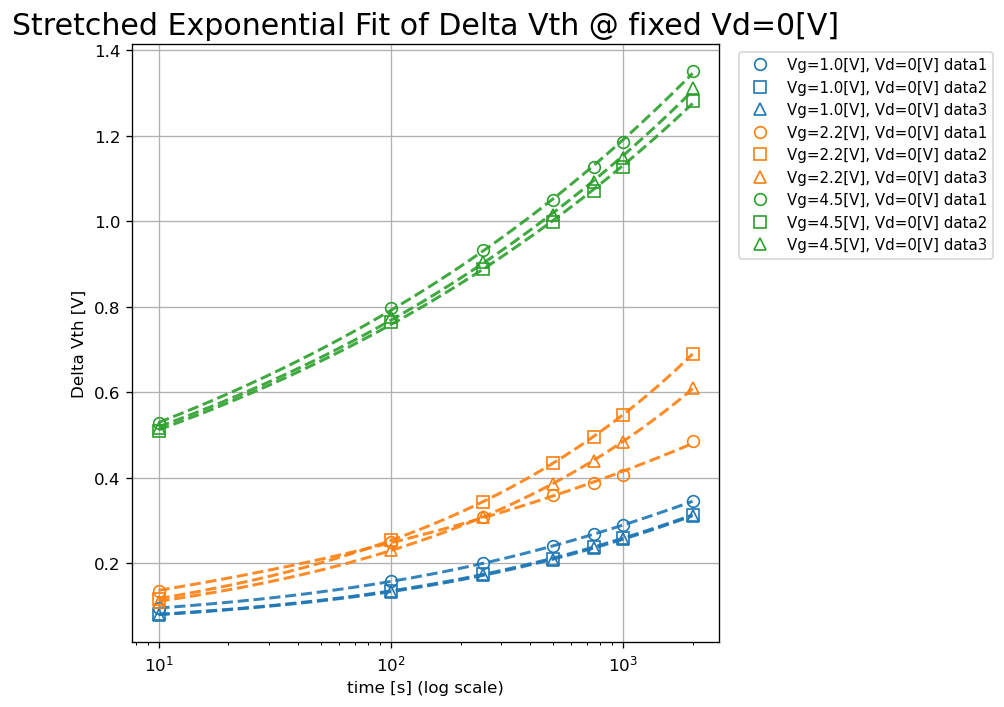

,legend,stress_vg[V],stress_vd[V],data_idx,V_pre[V],tau[s],beta,V_inf[V],fit_rmse[V]
0,"Vg=1.0[V], Vd=0[V] data1",1.0,0,1,0.5705,4.430355e+03,0.4241,0.6243,0.0006
1,"Vg=1.0[V], Vd=0[V] data2",1.0,0,2,0.5844,6.197418e+03,0.4352,0.6302,0.0005
2,"Vg=1.0[V], Vd=0[V] data3",1.0,0,3,0.6013,6.940098e+03,0.4389,0.6481,0.0007
3,"Vg=2.2[V], Vd=0[V] data1",2.2,0,1,15.6478,1.628502e+11,0.1819,15.5684,0.0045
4,"Vg=2.2[V], Vd=0[V] data2",2.2,0,2,334.2116,2.078459e+11,0.3349,334.2119,0.0007
5,"Vg=2.2[V], Vd=0[V] data3",2.2,0,3,282.1811,2.072086e+11,0.3334,282.1896,0.0013
6,"Vg=4.5[V], Vd=0[V] data1",4.5,0,1,44.1763,3.184653e+11,0.1853,44.2089,0.0039
7,"Vg=4.5[V], Vd=0[V] data2",4.5,0,2,34.9706,1.415000e+11,0.1840,35.0118,0.0037
8,"Vg=4.5[V], Vd=0[V] data3",4.5,0,3,42.4643,1.783075e+11,0.1924,42.5329,0.0045


In [78]:
def stretched_exponential(t, v_pre, tau, beta, v_inf):
    return -v_pre * np.exp(-((t / tau) ** beta)) + v_inf


fit_rows = []

plt.figure(figsize=(8, 6))

for result in results:
    delta_series = pd.Series(result["delta_vth_by_time"]).sort_index()
    delta_series = delta_series[(delta_series.index > 0) & (~delta_series.isna())]

    line_color = vg_color_map.get(result["vg"], 'black')
    line_marker = data_marker_map.get(result["data_idx"], 'o')

    fit_row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
        "data_idx": result["data_idx"],
        "V_pre[V]": np.nan,
        "tau[s]": np.nan,
        "beta": np.nan,
        "V_inf[V]": np.nan,
        "fit_rmse[V]": np.nan,
    }

    if len(delta_series) >= 4:
        x_data = delta_series.index.to_numpy(dtype=float)
        y_data = delta_series.to_numpy(dtype=float)

        v_inf_guess = float(np.nanmax(y_data))
        v_pre_guess = float(max(v_inf_guess - y_data[0], 1e-6))
        tau_guess = float(np.median(x_data))
        beta_guess = 0.5

        lower_bounds = [0.0, 1e-12, 0.0, -np.inf]
        upper_bounds = [np.inf, np.inf, 2.0, np.inf]

        try:
            popt, _ = curve_fit(
                stretched_exponential,
                x_data,
                y_data,
                p0=[v_pre_guess, tau_guess, beta_guess, v_inf_guess],
                bounds=(lower_bounds, upper_bounds),
                maxfev=20000,
            )

            y_fit = stretched_exponential(x_data, *popt)
            rmse = float(np.sqrt(np.mean((y_data - y_fit) ** 2)))

            fit_row["V_pre[V]"] = popt[0]
            fit_row["tau[s]"] = popt[1]
            fit_row["beta"] = popt[2]
            fit_row["V_inf[V]"] = popt[3]
            fit_row["fit_rmse[V]"] = rmse

            x_fit = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 300)
            y_fit_dense = stretched_exponential(x_fit, *popt)

            plt.plot(
                x_fit,
                y_fit_dense,
                color=line_color,
                linestyle='--',
                linewidth=1.8,
                alpha=0.9,
            )
        except RuntimeError:
            pass

    plt.plot(
        delta_series.index.to_numpy(),
        delta_series.to_numpy(),
        linestyle='None',
        color=line_color,
        marker=line_marker,
        markerfacecolor='none',
        markersize=7,
        label=result["label"],
    )

    fit_rows.append(fit_row)

plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('Delta Vth [V]')
plt.title('Stretched Exponential Fit of Delta Vth @ fixed Vd=0[V]', fontsize=18)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

fit_df = pd.DataFrame(fit_rows)
fit_df = fit_df.sort_values(["stress_vd[V]", "stress_vg[V]", "data_idx"]).reset_index(drop=True)
display(fit_df.round(4))


In [79]:
all_ss_times = sorted({time_s for result in results for time_s in result["ss_by_time"].keys()})

ss_rows = []
for result in results:
    row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
    }

    for time_s in all_ss_times:
        row[f"ss@{int(time_s)}s[mV/dec]"] = result["ss_by_time"].get(time_s, np.nan)

    ss_rows.append(row)

ss_df = pd.DataFrame(ss_rows)
ss_df = ss_df.sort_values(["stress_vd[V]", "stress_vg[V]", "legend"]).reset_index(drop=True)
display(ss_df.round(4))


,legend,stress_vg[V],stress_vd[V],ss@0s[mV/dec],ss@10s[mV/dec],ss@100s[mV/dec],ss@250s[mV/dec],ss@500s[mV/dec],ss@750s[mV/dec],ss@1000s[mV/dec],ss@2000s[mV/dec]
0,"Vg=1.0[V], Vd=0[V] data1",1.0,0,135.6606,133.7393,136.9459,137.5211,137.3501,136.9600,136.9413,136.2462
1,"Vg=1.0[V], Vd=0[V] data2",1.0,0,130.4772,131.1459,133.5059,136.0747,136.2432,135.0240,136.0029,135.2285
2,"Vg=1.0[V], Vd=0[V] data3",1.0,0,129.4938,131.2083,134.9148,135.8458,135.9395,137.1210,135.8261,135.4391
3,"Vg=2.2[V], Vd=0[V] data1",2.2,0,138.2958,141.1329,147.4168,150.4042,152.2552,151.5790,154.1015,153.5133
4,"Vg=2.2[V], Vd=0[V] data2",2.2,0,134.5805,139.7223,144.7700,146.1105,146.6502,146.8352,146.3423,145.2438
5,"Vg=2.2[V], Vd=0[V] data3",2.2,0,131.2627,135.5181,141.4146,143.8302,146.1504,146.4643,146.2040,145.5387
6,"Vg=4.5[V], Vd=0[V] data1",4.5,0,141.7508,149.5460,156.6787,159.5693,160.9161,162.0467,162.3134,161.6457
7,"Vg=4.5[V], Vd=0[V] data2",4.5,0,139.2949,146.4493,154.7710,158.0642,160.3619,161.3348,161.7672,162.6457
8,"Vg=4.5[V], Vd=0[V] data3",4.5,0,138.5989,147.1950,154.5600,158.5278,160.0601,161.8497,162.1875,162.4638


In [80]:
all_mu_times = sorted({time_s for result in results for time_s in result["mobility_by_time"].keys()})

mu_rows = []
for result in results:
    vd_values_used = [v for v in result["vd_used_by_time"].values() if not np.isnan(v)]
    row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
        "Cox_total[pF]": Cox_total_F * 1e12,
        "mu_calc_vd[V]": vd_values_used[0] if len(vd_values_used) > 0 else np.nan,
    }

    for time_s in all_mu_times:
        row[f"mu@{int(time_s)}s[cm^2/Vs]"] = result["mobility_by_time"].get(time_s, np.nan)

    mu_rows.append(row)

mu_df = pd.DataFrame(mu_rows)
mu_df = mu_df.sort_values(["stress_vd[V]", "stress_vg[V]", "legend"]).reset_index(drop=True)
display(mu_df.round(4))


,legend,stress_vg[V],stress_vd[V],Cox_total[pF],mu_calc_vd[V],mu@0s[cm^2/Vs],mu@10s[cm^2/Vs],mu@100s[cm^2/Vs],mu@250s[cm^2/Vs],mu@500s[cm^2/Vs],mu@750s[cm^2/Vs],mu@1000s[cm^2/Vs],mu@2000s[cm^2/Vs]
0,"Vg=1.0[V], Vd=0[V] data1",1.0,0,4.25,0.1,9.5831,9.8428,9.8673,9.8654,9.8146,9.8108,9.7864,9.6885
1,"Vg=1.0[V], Vd=0[V] data2",1.0,0,4.25,0.1,9.3713,9.5981,9.6527,9.6678,9.6565,9.6809,9.6602,9.6094
2,"Vg=1.0[V], Vd=0[V] data3",1.0,0,4.25,0.1,9.5624,9.8184,9.8579,9.8447,9.8202,9.7976,9.7619,9.6791
3,"Vg=2.2[V], Vd=0[V] data1",2.2,0,4.25,0.1,9.7958,10.1826,10.1252,10.0273,9.9501,9.8786,9.8372,9.6734
4,"Vg=2.2[V], Vd=0[V] data2",2.2,0,4.25,0.1,10.0141,10.4141,10.3228,10.1572,10.0028,9.8805,9.7638,9.2749
5,"Vg=2.2[V], Vd=0[V] data3",2.2,0,4.25,0.1,9.9153,10.3021,10.2268,10.0951,9.9407,9.8372,9.7600,9.4682
6,"Vg=4.5[V], Vd=0[V] data1",4.5,0,4.25,0.1,9.7506,9.5153,8.6473,8.1636,7.7048,7.3939,7.1383,6.3942
7,"Vg=4.5[V], Vd=0[V] data2",4.5,0,4.25,0.1,9.6904,9.3059,8.5896,8.1154,7.6745,7.3792,7.1386,6.4307
8,"Vg=4.5[V], Vd=0[V] data3",4.5,0,4.25,0.1,9.7374,9.2680,8.6146,8.1425,7.7007,7.3928,7.1654,6.4273
